<a href="https://colab.research.google.com/github/annabashlakova/ECON3916-Statistical-Machine-Learning/blob/main/Project_1_Econ_3916_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Phase 2**

In [ ]:
# I began with importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


In [ ]:
# Now I had to load the data
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/Ecdat/Mroz.csv"
df = pd.read_csv(url)

# Now I needed to delete a row index column
if 'Unamed: 0' in df.columns:
    df = df.drop(columns=['Unamed: 0'])

print(f"Dataset laoded: {df.shape[0]} observaions, {df.shape[1]} variables")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset laoded: 753 observaions, 19 variables

Columns: ['rownames', 'work', 'hoursw', 'child6', 'child618', 'agew', 'educw', 'hearnw', 'wagew', 'hoursh', 'ageh', 'educh', 'wageh', 'income', 'educwm', 'educwf', 'unemprate', 'city', 'experience']


,rownames,work,hoursw,child6,child618,agew,educw,hearnw,wagew,hoursh,ageh,educh,wageh,income,educwm,educwf,unemprate,city,experience
0,1,yes,1610,1,0,32,12,3.3540,2.65,2708,34,12,4.0288,16310,12,7,5.0,no,14
1,2,yes,1656,0,2,30,12,1.3889,2.65,2310,30,9,8.4416,21800,7,7,11.0,yes,5
2,3,yes,1980,1,3,35,12,4.5455,4.04,3072,40,12,3.5807,21040,12,7,5.0,no,15
3,4,yes,456,0,3,34,12,1.0965,3.25,1920,53,10,3.5417,7300,7,7,5.0,no,6
4,5,yes,1568,1,2,31,14,4.5918,3.60,2000,32,12,10.0000,27300,12,14,9.5,yes,7


In [ ]:
# Now to check the structure of every column I used .info() to show the names, non-null values and dta type

print(f"Dimensions: N = {df.shape[0]} observations, K = {df.shape[1]} variables\n")
df.info()

Dimensions: N = 753 observations, K = 19 variables

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rownames    753 non-null    int64  
 1   work        753 non-null    object 
 2   hoursw      753 non-null    int64  
 3   child6      753 non-null    int64  
 4   child618    753 non-null    int64  
 5   agew        753 non-null    int64  
 6   educw       753 non-null    int64  
 7   hearnw      753 non-null    float64
 8   wagew       753 non-null    float64
 9   hoursh      753 non-null    int64  
 10  ageh        753 non-null    int64  
 11  educh       753 non-null    int64  
 12  wageh       753 non-null    float64
 13  income      753 non-null    int64  
 14  educwm      753 non-null    int64  
 15  educwf      753 non-null    int64  
 16  unemprate   753 non-null    float64
 17  city        753 non-null    object 
 18  experience  753 no

In [ ]:
# After I used .describe() to give me the count, mean, std, min, quadrats, and max

df.describe().round(2)

,rownames,hoursw,child6,child618,agew,educw,hearnw,wagew,hoursh,ageh,educh,wageh,income,educwm,educwf,unemprate,experience
count,753.00,753.00,753.00,753.00,753.00,753.00,753.00,753.00,753.00,753.00,753.00,753.00,753.00,753.00,753.00,753.00,753.00
mean,377.00,740.58,0.24,1.35,42.54,12.29,2.37,1.85,2267.27,45.12,12.49,7.48,23080.59,9.25,8.81,8.62,10.63
std,217.52,871.31,0.52,1.32,8.07,2.28,3.24,2.42,595.57,8.06,3.02,4.23,12190.20,3.37,3.57,3.11,8.07
min,1.00,0.00,0.00,0.00,30.00,5.00,0.00,0.00,175.00,30.00,3.00,0.41,1500.00,0.00,0.00,3.00,0.00
25%,189.00,0.00,0.00,0.00,36.00,12.00,0.00,0.00,1928.00,38.00,11.00,4.79,15428.00,7.00,7.00,7.50,4.00
50%,377.00,288.00,0.00,1.00,43.00,12.00,1.62,0.00,2164.00,46.00,12.00,6.98,20880.00,10.00,7.00,7.50,9.00
75%,565.00,1516.00,0.00,2.00,49.00,13.00,3.79,3.58,2553.00,52.00,15.00,9.17,28200.00,12.00,12.00,11.00,15.00
max,753.00,4950.00,3.00,8.00,60.00,17.00,25.00,9.98,5010.00,60.00,17.00,40.51,96000.00,17.00,17.00,14.00,45.00


In [ ]:
# Then I had to check for dirty data (looking for columns stored as strings)
object_cols = df.select_dtypes(include='object').columns.tolist()
# If string columns were found I needed to find their names and values
if len(object_cols) > 0:
    print(f"String columns found: {object_cols}")
    for col in object_cols:
      print(f"\n '{col}' unique values: {df[col].unique()}")
else:
    print("No string columns found.")

String columns found: ['work', 'city']

 'work' unique values: ['yes' 'no']

 'city' unique values: ['no' 'yes']


In [ ]:
# First I cleaned the work column, converting it from yes/no to 0/1

print("Before cleaning:")
print(f" 'work' dtype: {df['work'].dtype}")
print(f" 'work' unique values: {df['work'].unique()}")

# now .map() yo replace every yes with 1 and each no with 0
df['work'] = df['work'].map({'yes':1,'no':0})

print(f"\nAfter cleaning:")
print(f" 'work' dtype: {df['work'].dtype}")
print(f" 'work' unique values: {df['work'].unique()}")


Before cleaning:
 'work' dtype: object
 'work' unique values: ['yes' 'no']

After cleaning:
 'work' dtype: int64
 'work' unique values: [1 0]


In [ ]:
# Now had to clean the city column, as I am not analysing it I am not printing the before values

df['city'] = df['city'].map({'yes':1, 'no': 0})

# Confirming no more string columns
remaining_objects = df.select_dtypes(include='object').columns.tolist()
print(f"Remaining string columns: {remaining_objects if remaining_objects else 'All clean'}")

Remaining string columns: All clean


In [ ]:
#Task 2 - Missing Values

# First I had to check if any columns had missing values, i used .isnull().sum()
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_report = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing'] > 0]

if len(missing_report) > 0:
  print("Variables with missing values:")
  print(missing_report)
else:
  print("No NaN values found")
  print(f"Total cells checked: {df.shape[0]} rows x {df.shape[1]} columns = {df.shape[0] * df.shape[1]:,}cells")

No NaN values found
Total cells checked: 753 rows x 19 columns = 14,307cells


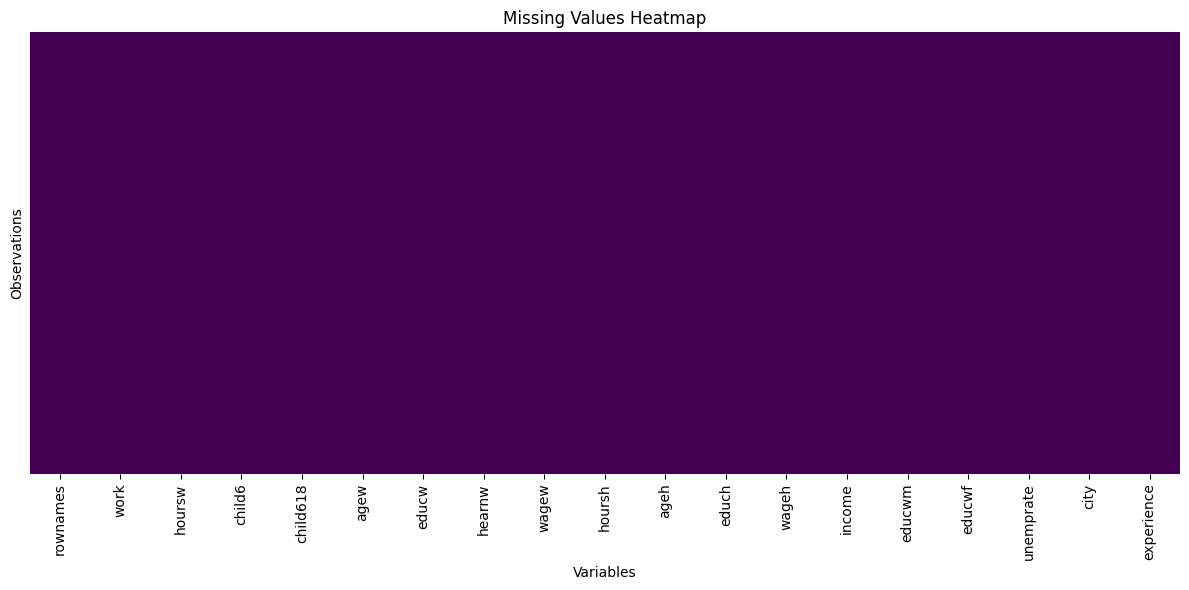

In [ ]:
# Now heatmap visualization

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=12)
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.tight_layout()
plt.show()
# Purple = data present, yellow = data missing

In [ ]:
# As shown there are no NaN values however 'hearnw' (wife's wage)=0 for all women who chose not to work which is inaccurate as it refelcts the wage as 0/wage whilst they just didnt have a job
# So the wage data is technically missinh for women who chose not to work

workers = df[df['work']== 1]
non_workers = df[df['work']==0]

print(f"Women in labor force(work = 1): {len(workers)}")
print(f"Women not in labor force(work = 0): {len(non_workers)}")

print(f"\nHourly earnings ('hearnw):")
print(f" workers mean: ${workers['hearnw'].mean():.2f}")
print(f" workers median: ${workers['hearnw'].median():.2f}")
print(f" non-workers mean: ${non_workers['hearnw'].mean():.2f}")


Women in labor force(work = 1): 428
Women not in labor force(work = 0): 325

Hourly earnings ('hearnw):
 workers mean: $4.18
 workers median: $3.48
 non-workers mean: $0.00


As mentioned there is an issue with the 'hearnw' variable as it reflects a not real zero, as there is no wage to observe in the first place as these 325 women just chose not to work. This ties into investigation as the wage data is missing particularly to whether women chose to work or not, influenced by variables researched in this project - children, education, husband's income, and age. That means there is a pattern behind it, so dropping all 325 rows of that data would be wrong, so I kept all observations.

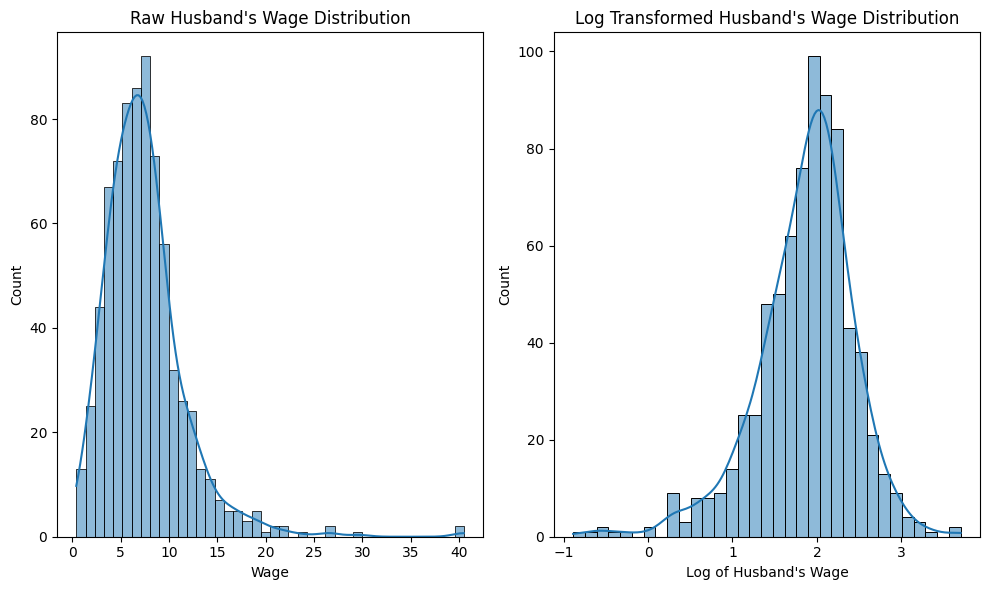

In [ ]:
# Now I will plot the raw distirbution in comparison to the log transformed one
plt.figure(figsize=(10,6))

# First the raw husband's wage
plt.subplot(1,2,1)
sns.histplot(df['wageh'], kde=True)
plt.title("Raw Husband's Wage Distribution")
plt.xlabel("Wage")

# Now the log transformed
plt.subplot(1,2,2)
positive_wages = df[df['wageh'] > 0]['wageh']
sns.histplot(np.log(positive_wages), kde=True)
plt.title("Log Transformed Husband's Wage Distribution")
plt.xlabel("Log of Husband's Wage")

plt.tight_layout()
plt.show()

In the raw distribution the data is right skewed cause although most make in the normal range a few happen to make more stretching the distribution, the log transformation compresses the big values and spreads out the smaller ones.

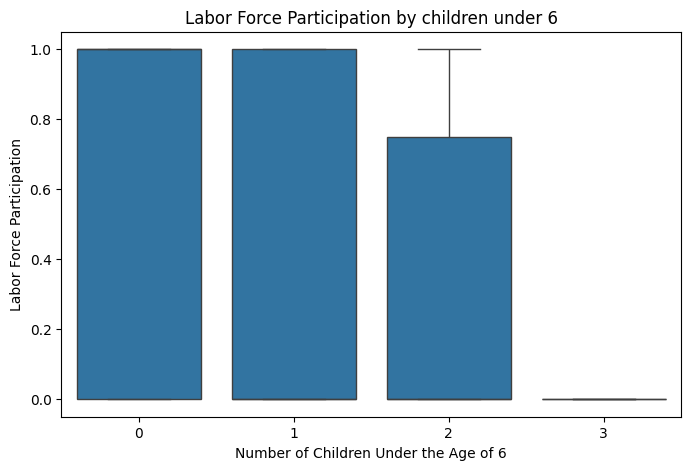

In [ ]:
# Now I will plot the relationship between child6 and work, I needed to use a box plot as work is binary and children count is discrete

plt.figure(figsize=(8,5))
sns.boxplot(x='child6', y='work', data=df)
plt.title("Labor Force Participation by children under 6")
plt.xlabel("Number of Children Under the Age of 6")
plt.ylabel("Labor Force Participation")
plt.show()


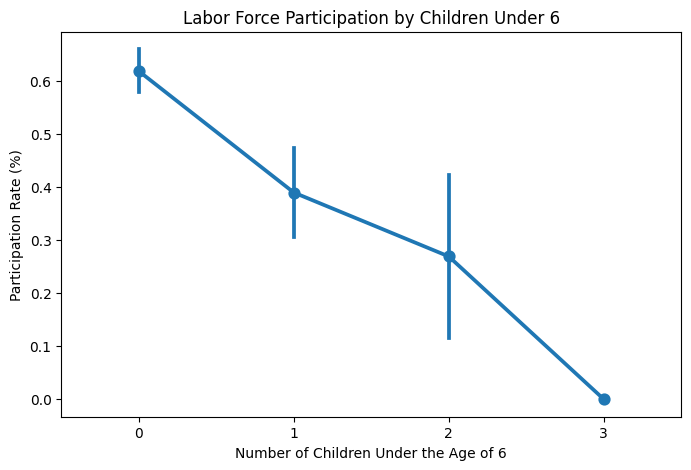

In [ ]:
# I decided a better approach would be to group women by the amount of young kids they hace and calculate what percentage of each group works
# This was done as the box plot (due to it being binary) does not show the spread
plt.figure(figsize=(8,5))
sns.pointplot(x='child6', y='work', data=df)
plt.title("Labor Force Participation by Children Under 6")
plt.xlabel("Number of Children Under the Age of 6")
plt.ylabel("Participation Rate (%)")
plt.show()

Now we can see a clear downwards trend, as the number of children under 6 increases the labour force participation drops.

In [ ]:
# At last I needed to detect the Outliers, as the Project required I used the Tukey Fence method (IQR*1.5)

Q1 = df['wageh'].quantile(0.25)
Q3 = df['wageh'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['wageh'] < (Q1 - 1.5 * IQR)) | (df['wageh'] > (Q3 + 1.5 * IQR))]

print(f"Q1 = {Q1:.3f}")
print(f"Q3 = {Q3:.3f}")
print(f"IQR = {IQR:.3f}")
print(f"Lower Fence = {Q1 - 1.5 * IQR:.3f}")
print(f"Upper Fence = {Q3 + 1.5 * IQR:.3f}")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")


Q1 = 4.788
Q3 = 9.167
IQR = 4.378
Lower Fence = -1.779
Upper Fence = 15.734
Outliers detected: 29 (3.9%)


I also decided to test for outliers in all my other control variables so for the future investigation I will be sure that no data will mess up the regression.

In [ ]:
# First outliers for education (educw)
Q1 = df['educw'].quantile(0.25)
Q3 = df['educw'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['educw'] < (Q1 - 1.5 * IQR)) | (df['educw'] > (Q3 + 1.5 * IQR))]

print(f"Q1 = {Q1:.3f}")
print(f"Q3 = {Q3:.3f}")
print(f"IQR = {IQR:.3f}")
print(f"Lower Fence = {Q1 - 1.5 * IQR:.3f}")
print(f"Upper Fence = {Q3 + 1.5 * IQR:.3f}")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

Q1 = 12.000
Q3 = 13.000
IQR = 1.000
Lower Fence = 10.500
Upper Fence = 14.500
Outliers detected: 234 (31.1%)


In [ ]:
# outliers for age (agew)
Q1 = df['agew'].quantile(0.25)
Q3 = df['agew'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['agew'] < (Q1 - 1.5 * IQR)) | (df['agew'] > (Q3 + 1.5 * IQR))]

print(f"Q1 = {Q1:.3f}")
print(f"Q3 = {Q3:.3f}")
print(f"IQR = {IQR:.3f}")
print(f"Lower Fence = {Q1 - 1.5 * IQR:.3f}")
print(f"Upper Fence = {Q3 + 1.5 * IQR:.3f}")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

Q1 = 36.000
Q3 = 49.000
IQR = 13.000
Lower Fence = 16.500
Upper Fence = 68.500
Outliers detected: 0 (0.0%)


In [ ]:
# outlier for experience (experience)
Q1 = df['experience'].quantile(0.25)
Q3 = df['experience'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['experience'] < (Q1 - 1.5 * IQR)) | (df['experience'] > (Q3 + 1.5 * IQR))]

print(f"Q1 = {Q1:.3f}")
print(f"Q3 = {Q3:.3f}")
print(f"IQR = {IQR:.3f}")
print(f"Lower Fence = {Q1 - 1.5 * IQR:.3f}")
print(f"Upper Fence = {Q3 + 1.5 * IQR:.3f}")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

Q1 = 4.000
Q3 = 15.000
IQR = 11.000
Lower Fence = -12.500
Upper Fence = 31.500
Outliers detected: 16 (2.1%)


Summary of findings: The tukey fence method mainly flagged wageh and educw. For husband's income as explained there are a few who make significantly above the normal range so the outliers make sense. For education, 234 observations came back as ouliers this means that most women have identical educational levels so the IQR is very narrow so even a slight deviation results in an outlier. So I flagged them but I did not remove them, I will just keep it in mind later on in the project.

**Now I will move on to Phase 3**

In [ ]:
import statsmodels.formula.api as smf
# I did not use np.log() as the Y(work) is binary (0/1)
formula_1 = 'work ~ child6 + educw + wageh + agew + experience'
model_1 = smf.ols(formula=formula_1, data=df).fit(cov_type='HC1')
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                   work   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     78.20
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           5.71e-66
Time:                        14:10:20   Log-Likelihood:                -430.29
No. Observations:                 753   AIC:                             872.6
Df Residuals:                     747   BIC:                             900.3
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7845      0.134      5.874      0.0

Step 3.1 helped my find that the R squared value is 0.252 meaning that this model explains around 25% of the variation found in the labour force participation. Now looking at child6 = -0.277 which means that each additional kid under 6 years old decreases the probability of labour force participation by about 27.7%. For the control variables that this project is looking at: educw = 0.0382 each extra year of eductaion leads to an increase in work, wageh = -0.0074 weak significance (p = 0.066), agew = -0.0189 shows that older women are less likely to join the workforce, experience = 0.0228, more experienced women are likely to work more than unexperienced.

In [ ]:
# Step 3.2: Testing Heterogeneity
# Now i iwll test if the effect of children under 6 is different by education level
formula_interact = 'work ~ child6 * educw + wageh + agew + experience'
model_interact = smf.ols(formula=formula_interact, data=df).fit(cov_type='HC1')
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                   work   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     64.94
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           7.06e-65
Time:                        14:10:20   Log-Likelihood:                -430.20
No. Observations:                 753   AIC:                             874.4
Df Residuals:                     746   BIC:                             906.8
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.8008      0.138      5.784   

As seen by the interaction model child6:educw = 0.0053(p=0.684) meaning it is not significant so the effect of young children on labour force does not signficantly differ by education level. So the negative effects on the female labour force participation does not correlate with education levels, no heterogeneity.

In [ ]:
# Running the second and final test to see if wageh has an effect on child6

formula_interact2 = 'work ~ child6 * wageh + educw + agew + experience'
model_interact2 = smf.ols(formula=formula_interact2, data=df).fit(cov_type='HC1')
print(model_interact2.summary())

                            OLS Regression Results                            
Dep. Variable:                   work   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     65.51
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           2.34e-65
Time:                        14:10:20   Log-Likelihood:                -429.92
No. Observations:                 753   AIC:                             873.8
Df Residuals:                     746   BIC:                             906.2
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.7731      0.134      5.767   

I also decided to test correlation between wageh and child6 as if the husband earns more family can afford childcare and relating expenses, possibly meaning that the kdis do not reduce the participation as much. We can see that p=0.365, so it is not significant and young children reduce participation by similiar amounts.

**Phase 4**

In [ ]:
# Step 4.1: Running the three progressive OLS specifications
import statsmodels.formula.api as smf
# First Model only with the key variable
formula_m1 = 'work ~ child6'
model_1 = smf.ols(formula=formula_m1, data=df).fit(cov_type='HC1')

# Second model will also have all the controls
formula_m2 = 'work ~ child6 + educw + wageh + agew + experience'
model_2 = smf.ols(formula=formula_m2, data=df).fit(cov_type='HC1')

# The third model is the full model with the interaction term included
formula_m3 = 'work ~ child6 * educw + wageh + agew + experience'
model_3 = smf.ols(formula=formula_m3, data=df).fit(cov_type='HC1')

print("Model 1: Baseline")
print(model_1.summary())

print("Model 2: Multivariate")
print(model_2.summary())

print("Model 3: Multivariate with Interaction")
print(model_3.summary())

Model 1: Baseline
                            OLS Regression Results                            
Dep. Variable:                   work   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     42.82
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.11e-10
Time:                        14:10:20   Log-Likelihood:                -521.80
No. Observations:                 753   AIC:                             1048.
Df Residuals:                     751   BIC:                             1057.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6165      0.019  

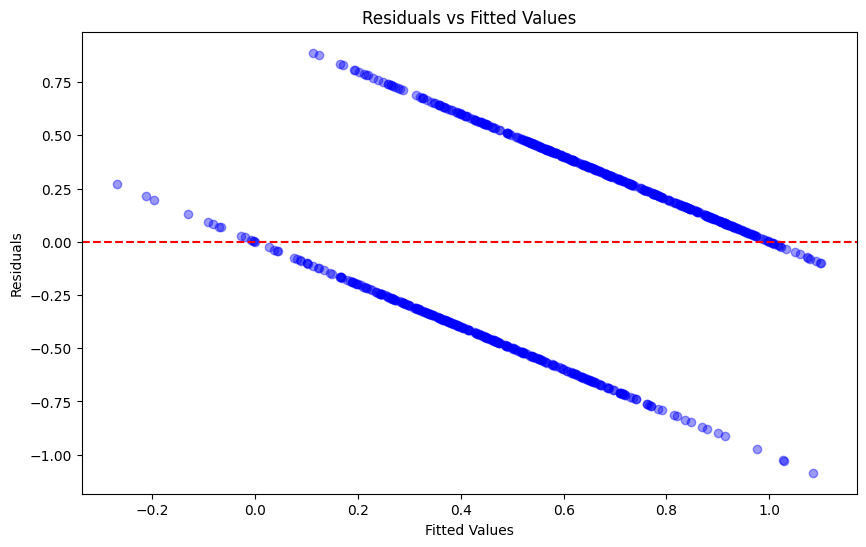

In [ ]:
# Step 4.2: Validating Assumptions
# First I will run a diagnostic residual vs fitted values
import matplotlib.pyplot as plt
import numpy as np

fitted = model_2.fittedvalues
resids = model_2.resid

plt.figure(figsize=(10,6))
plt.scatter(fitted,resids,alpha=0.4, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

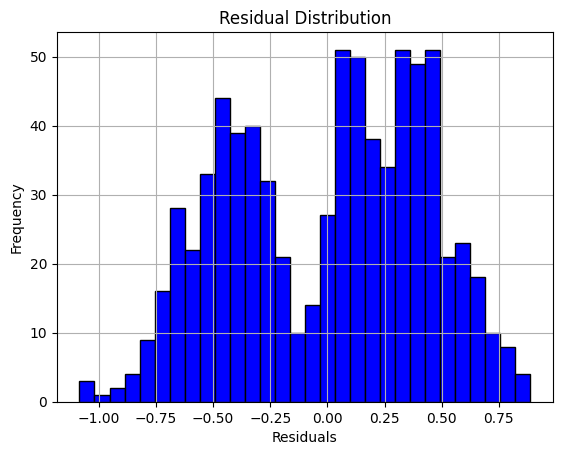

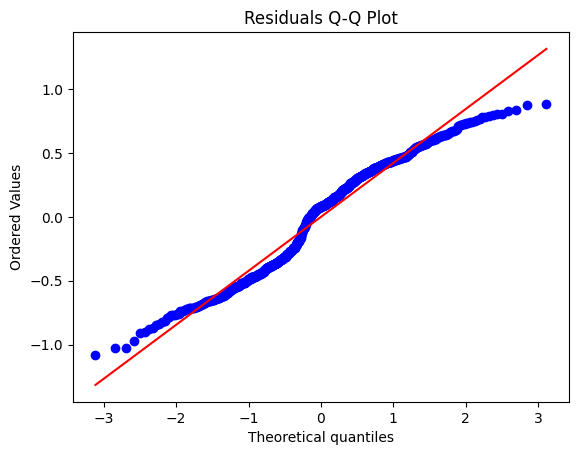

Skewness: -0.1835
Kurtosis: -1.0342


In [ ]:
# Continuing Step 4.2 I will run a second diagnostic on the distribution of Residuals
# As my Y is binary the residuals will not be normal, I will flag it
import scipy.stats as stats

# Now i will create a histogram
resids.hist(bins=30, color='blue', edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.show()

stats.probplot(resids, dist='norm', plot=plt)
plt.title('Residuals Q-Q Plot')
plt.show()

print(f"Skewness: {resids.skew():.4f}")
print(f"Kurtosis: {resids.kurtosis():.4f}")

In [ ]:
# Final stage of step 4.2
# Now i will check if the result will hold without outliers and rerun model 2 on the trimmed sample

std_resids = (resids - resids.mean())/resids.std()
clean_df = df[np.abs(std_resids)<= 2].copy()

print(f"Orignal N: {len(df)}")
print(f"Trimmed N: {len(clean_df)}")
formula_robust = 'work ~ child6 + educw + wageh + agew + experience'
model_robust = smf.ols(formula=formula_robust, data=clean_df).fit(cov_type='HC1')

print(model_robust.summary())

Orignal N: 753
Trimmed N: 743
                            OLS Regression Results                            
Dep. Variable:                   work   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     118.6
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           5.09e-92
Time:                        14:23:19   Log-Likelihood:                -403.13
No. Observations:                 743   AIC:                             818.3
Df Residuals:                     737   BIC:                             845.9
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7828 

In [ ]:
# Creating Table 1 for the final report
df['treated'] = (df['child6']>0).astype(int)

table1 = df.groupby('treated')[['work', 'educw', 'wageh', 'agew', 'experience','child6']].mean().round(3).T
table1.columns = ['Control (no young children)', 'Treated (young children)']
print(table1)
print(f"\nControl N: {(df['treated']==0).sum()}")
print(f'Treated N: {(df['treated']==1).sum()}')

            Control (no young children)  Treated (young children)
work                              0.619                     0.361
educw                            12.188                    12.694
wageh                             7.414                     7.762
agew                             44.317                    35.204
experience                       11.503                     7.034
child6                            0.000                     1.218

Control N: 606
Treated N: 147
